## Question 1: Text Generation using GRU

In [1]:
import numpy as np
import tensorflow as tf
import nltk
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences



2026-03-28 22:12:50.942128: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:

nltk.download('gutenberg')
text = nltk.corpus.gutenberg.raw('austen-emma.txt').lower()


text = text[:200000]   

vocab_size = 5000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts([text])


sequences = tokenizer.texts_to_sequences([text])[0]


seq_len = 20
input_sequences = []

for i in range(seq_len, len(sequences)):
    input_sequences.append(sequences[i-seq_len:i+1])

input_sequences = np.array(input_sequences)


X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = tf.keras.utils.to_categorical(y, num_classes=vocab_size)


[nltk_data] Downloading package gutenberg to /Users/mac/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


In [3]:
model = Sequential([
    Embedding(vocab_size, 64, input_length=seq_len),
    GRU(128),
    Dense(vocab_size, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


model.fit(X, y, epochs=20, batch_size=128)


/opt/miniconda3/envs/nlp310/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.0347 - loss: 6.5669
Epoch 2/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.0599 - loss: 5.9514
Epoch 3/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.0876 - loss: 5.6200
Epoch 4/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.1098 - loss: 5.3567
Epoch 5/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.1255 - loss: 5.1459
Epoch 6/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.1380 - loss: 4.9605
Epoch 7/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.1497 - loss: 4.7916
Epoch 8/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.1590 - loss: 4.6346
Epoch 9/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.1685 - loss: 4.4835
Epoch 10/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.1790 - loss: 4.3384
Epoch 11/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.1891 - loss: 4.1976
Epoch 12/20
286/286 ━━━━━━━━━━

In [4]:

model = Sequential([
    Embedding(vocab_size, 128, input_length=seq_len),
    GRU(256),
    Dense(vocab_size, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


model.fit(X, y, epochs=20, batch_size=128)




Epoch 1/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.0365 - loss: 6.5648
Epoch 2/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 22s 76ms/step - accuracy: 0.0794 - loss: 5.8033
Epoch 3/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 22s 77ms/step - accuracy: 0.1089 - loss: 5.4054
Epoch 4/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 22s 77ms/step - accuracy: 0.1304 - loss: 5.1131
Epoch 5/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 22s 77ms/step - accuracy: 0.1490 - loss: 4.8553
Epoch 6/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 22s 77ms/step - accuracy: 0.1659 - loss: 4.5989
Epoch 7/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 22s 77ms/step - accuracy: 0.1815 - loss: 4.3346
Epoch 8/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 22s 78ms/step - accuracy: 0.2033 - loss: 4.0516
Epoch 9/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step - accuracy: 0.2329 - loss: 3.7613
Epoch 10/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step - accuracy: 0.2724 - loss: 3.4679
Epoch 11/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.3156 - loss: 3.1790
Epoch 12/20
286/286 ━━━━━━━━━━

In [5]:
from tensorflow.keras.optimizers import Adam

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 128, input_length=seq_len),
    tf.keras.layers.GRU(256, dropout=0.2, recurrent_dropout=0.2),
    tf.keras.layers.Dense(vocab_size, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.fit(X, y, epochs=20, batch_size=128, validation_split=0.2)

Epoch 1/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 29s 115ms/step - accuracy: 0.0347 - loss: 6.6375 - val_accuracy: 0.0519 - val_loss: 6.3893
Epoch 2/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 30s 132ms/step - accuracy: 0.0676 - loss: 5.8959 - val_accuracy: 0.0880 - val_loss: 6.0873
Epoch 3/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 32s 140ms/step - accuracy: 0.1007 - loss: 5.4765 - val_accuracy: 0.1002 - val_loss: 5.9318
Epoch 4/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 30s 130ms/step - accuracy: 0.1190 - loss: 5.1832 - val_accuracy: 0.1092 - val_loss: 5.8711
Epoch 5/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 30s 133ms/step - accuracy: 0.1396 - loss: 4.9331 - val_accuracy: 0.1187 - val_loss: 5.8423
Epoch 6/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 31s 137ms/step - accuracy: 0.1559 - loss: 4.6934 - val_accuracy: 0.1179 - val_loss: 5.8727
Epoch 7/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 31s 135ms/step - accuracy: 0.1710 - loss: 4.4576 - val_accuracy: 0.1203 - val_loss: 5.9172
Epoch 8/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 31s 133ms/step - accuracy: 0.1863 - loss: 4

In [24]:
from tensorflow.keras.optimizers import Adam

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 128, input_length=seq_len),
    tf.keras.layers.GRU(256, dropout=0.1, recurrent_dropout=0.1),
    tf.keras.layers.Dense(vocab_size, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.fit(X, y, epochs=20, batch_size=128, validation_split=0.2)

Epoch 1/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - accuracy: 0.0382 - loss: 6.6079 - val_accuracy: 0.0482 - val_loss: 6.3336
Epoch 2/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 24s 105ms/step - accuracy: 0.0746 - loss: 5.8278 - val_accuracy: 0.0896 - val_loss: 6.0179
Epoch 3/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 25s 107ms/step - accuracy: 0.1042 - loss: 5.4056 - val_accuracy: 0.1040 - val_loss: 5.8676
Epoch 4/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 24s 103ms/step - accuracy: 0.1287 - loss: 5.1083 - val_accuracy: 0.1137 - val_loss: 5.8213
Epoch 5/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 24s 103ms/step - accuracy: 0.1456 - loss: 4.8446 - val_accuracy: 0.1182 - val_loss: 5.8362
Epoch 6/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - accuracy: 0.1609 - loss: 4.5923 - val_accuracy: 0.1171 - val_loss: 5.8738
Epoch 7/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 24s 103ms/step - accuracy: 0.1779 - loss: 4.3414 - val_accuracy: 0.1171 - val_loss: 5.9383
Epoch 8/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 24s 104ms/step - accuracy: 0.1954 - loss: 4

In [6]:

index_word = {v: k for k, v in tokenizer.word_index.items()}
def generate_text(seed_text, next_words, temperature=0.8):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = token_list[-seq_len:]
        token_list = pad_sequences([token_list], maxlen=seq_len, padding='pre')

        preds = model.predict(token_list, verbose=0)[0]


        preds = np.log(preds + 1e-8) / temperature
        preds = np.exp(preds)
        preds = preds / np.sum(preds)

        predicted = np.random.choice(len(preds), p=preds)

        word = index_word.get(predicted, "")

        seed_text += " " + word

    return seed_text


print(generate_text("she was", 20))

she was very fond of singing he could sing to the early hours and civil days the narrow slippery path through the


##Q2: POS Tagging using GRU + LSTM

In [7]:
import nltk
import numpy as np
import tensorflow as tf
from nltk.corpus import treebank
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split



In [8]:

nltk.download('treebank')
sentences = treebank.tagged_sents()


words = [[w.lower() for w, t in sent] for sent in sentences]
tags = [[t for w, t in sent] for sent in sentences]


word2idx = {"PAD": 0, "UNK": 1}

for sent in words:
    for word in sent:
        if word not in word2idx:
            word2idx[word] = len(word2idx)

unique_tags = list(set(tag for sent in tags for tag in sent))

tag2idx = {tag: idx for idx, tag in enumerate(unique_tags)}
tag2idx["PAD"] = len(tag2idx)

idx2tag = {idx: tag for tag, idx in tag2idx.items()}

X = [[word2idx.get(w, word2idx["UNK"]) for w in sent] for sent in words]
y = [[tag2idx[tag] for tag in sent] for sent in tags]

max_len = 50

X = pad_sequences(X, maxlen=max_len, padding='post', value=word2idx["PAD"])
y = pad_sequences(y, maxlen=max_len, padding='post', value=tag2idx["PAD"])

y = tf.keras.utils.to_categorical(y, num_classes=len(tag2idx))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

[nltk_data] Downloading package treebank to /Users/mac/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


In [9]:

gru_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(len(word2idx), 64, mask_zero=True),
    tf.keras.layers.GRU(64, return_sequences=True),
    tf.keras.layers.TimeDistributed( 
        tf.keras.layers.Dense(len(tag2idx), activation='softmax')
    )
])

gru_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\nTraining GRU model...")
gru_model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))


Training GRU model...
Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.2671 - loss: 3.2074 - val_accuracy: 0.4570 - val_loss: 2.4143
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5515 - loss: 1.8663 - val_accuracy: 0.6535 - val_loss: 1.4825
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7392 - loss: 1.1577 - val_accuracy: 0.8021 - val_loss: 0.9415
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8663 - loss: 0.7049 - val_accuracy: 0.8627 - val_loss: 0.6275
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9157 - loss: 0.4455 - val_accuracy: 0.8895 - val_loss: 0.4704


In [10]:

gru_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(len(word2idx), 128, mask_zero=True),
    tf.keras.layers.GRU(128, return_sequences=True),
    tf.keras.layers.TimeDistributed( 
        tf.keras.layers.Dense(len(tag2idx), activation='softmax')
    )
])

gru_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\nTraining GRU model...")
gru_model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))



Training GRU model...
Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.4163 - loss: 2.8303 - val_accuracy: 0.5396 - val_loss: 1.8336
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.6986 - loss: 1.2959 - val_accuracy: 0.8058 - val_loss: 0.8996
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.8763 - loss: 0.6032 - val_accuracy: 0.8788 - val_loss: 0.5048
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.9345 - loss: 0.3208 - val_accuracy: 0.9016 - val_loss: 0.3670
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.9554 - loss: 0.2012 - val_accuracy: 0.9111 - val_loss: 0.3109


In [11]:
gru_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(len(word2idx), 128, mask_zero=True),
    tf.keras.layers.GRU(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
    tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(len(tag2idx), activation='softmax')
    )
])

gru_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

gru_model.fit(X_train, y_train, epochs=5, batch_size=64,
              validation_data=(X_test, y_test))

Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.4051 - loss: 2.8616 - val_accuracy: 0.5391 - val_loss: 1.8820
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.6703 - loss: 1.3699 - val_accuracy: 0.7884 - val_loss: 0.9604
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.8644 - loss: 0.6647 - val_accuracy: 0.8729 - val_loss: 0.5339
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.9243 - loss: 0.3608 - val_accuracy: 0.9008 - val_loss: 0.3834
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.9492 - loss: 0.2297 - val_accuracy: 0.9097 - val_loss: 0.3197


In [12]:
lstm_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(len(word2idx), 64, mask_zero=True),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(len(tag2idx), activation='softmax')
    )
])

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\nTraining LSTM model...")
lstm_model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))



Training LSTM model...
Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.1850 - loss: 3.3616 - val_accuracy: 0.2334 - val_loss: 2.9640
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3739 - loss: 2.5774 - val_accuracy: 0.4637 - val_loss: 2.2089
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5115 - loss: 1.8769 - val_accuracy: 0.5711 - val_loss: 1.6544
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.6568 - loss: 1.3835 - val_accuracy: 0.7159 - val_loss: 1.2172
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7993 - loss: 0.9551 - val_accuracy: 0.8293 - val_loss: 0.8602


In [13]:

lstm_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(len(word2idx), 128, mask_zero=True),
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(len(tag2idx), activation='softmax')
    )
])

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\nTraining LSTM model...")
lstm_model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))



Training LSTM model...
Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.2337 - loss: 3.1479 - val_accuracy: 0.3829 - val_loss: 2.5495
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.4877 - loss: 2.0119 - val_accuracy: 0.5833 - val_loss: 1.5897
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.7199 - loss: 1.1793 - val_accuracy: 0.8147 - val_loss: 0.8931
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.8842 - loss: 0.6039 - val_accuracy: 0.8786 - val_loss: 0.5393
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.9348 - loss: 0.3385 - val_accuracy: 0.9023 - val_loss: 0.4002


In [14]:
lstm_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(len(word2idx), 128, mask_zero=True),
    tf.keras.layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
    tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(len(tag2idx), activation='softmax')
    )
])

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

lstm_model.fit(X_train, y_train, epochs=5, batch_size=64,
               validation_data=(X_test, y_test))

Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.2196 - loss: 3.1741 - val_accuracy: 0.3750 - val_loss: 2.5853
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.4832 - loss: 2.0292 - val_accuracy: 0.5687 - val_loss: 1.6003
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.6916 - loss: 1.2377 - val_accuracy: 0.7944 - val_loss: 0.9508
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.8631 - loss: 0.6817 - val_accuracy: 0.8733 - val_loss: 0.5795
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.9253 - loss: 0.3907 - val_accuracy: 0.8966 - val_loss: 0.4238


In [15]:

print("\nEvaluating Models...")
print("GRU Accuracy:", gru_model.evaluate(X_test, y_test))
print("LSTM Accuracy:", lstm_model.evaluate(X_test, y_test))


def predict_sentence(sentence, model):
    tokens = [word2idx.get(w.lower(), word2idx["UNK"]) for w in sentence.split()]
    tokens = pad_sequences([tokens], maxlen=max_len, padding='post')

    preds = model.predict(tokens, verbose=0)
    pred_tags = [idx2tag[np.argmax(p)] for p in preds[0]]

    return list(zip(sentence.split(), pred_tags[:len(sentence.split())]))

# Test sentence
sample = "The market is growing fast"
print("\nSample Prediction (LSTM):")
print(predict_sentence(sample, lstm_model))


Evaluating Models...
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9097 - loss: 0.3200
GRU Accuracy: [0.3199911415576935, 0.9096986055374146]
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8966 - loss: 0.4244
LSTM Accuracy: [0.4243648052215576, 0.8966319561004639]

Sample Prediction (LSTM):
[('The', 'DT'), ('market', 'NN'), ('is', 'VBZ'), ('growing', 'VBG'), ('fast', 'JJ')]


##Q3: RNN vs LSTM vs GRU (COMPARISON)

In [16]:
import numpy as np
import tensorflow as tf
import nltk
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU
import matplotlib.pyplot as plt



In [17]:

nltk.download('gutenberg')
text = nltk.corpus.gutenberg.raw('austen-emma.txt').lower()


text = text[:200000]


vocab_size = 5000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts([text])

total_words = vocab_size  

sequences = tokenizer.texts_to_sequences([text])[0]


seq_len = 20
input_sequences = []

for i in range(seq_len, len(sequences)):
    input_sequences.append(sequences[i-seq_len:i+1])

input_sequences = np.array(input_sequences)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = tf.keras.utils.to_categorical(y, num_classes=total_words)


[nltk_data] Downloading package gutenberg to /Users/mac/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


In [18]:

def build_model(cell_type):
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(total_words, 64, input_length=seq_len),
        cell_type(128),
        tf.keras.layers.Dense(total_words, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


rnn_model = build_model(SimpleRNN)
lstm_model = build_model(LSTM)
gru_model = build_model(GRU)


print("Training RNN...")
rnn_hist = rnn_model.fit(X, y, epochs=10, batch_size=128, verbose=1)

print("Training LSTM...")
lstm_hist = lstm_model.fit(X, y, epochs=10, batch_size=128, verbose=1)

print("Training GRU...")
gru_hist = gru_model.fit(X, y, epochs=10, batch_size=128, verbose=1)


Training RNN...
Epoch 1/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.0301 - loss: 6.5396
Epoch 2/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.0417 - loss: 6.1736
Epoch 3/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.0590 - loss: 5.9486
Epoch 4/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.0891 - loss: 5.6340
Epoch 5/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.1091 - loss: 5.3491
Epoch 6/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.1252 - loss: 5.1130
Epoch 7/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.1384 - loss: 4.9036
Epoch 8/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.1511 - loss: 4.7069
Epoch 9/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.1625 - loss: 4.5172
Epoch 10/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.1763 - loss: 4.3349
Training LSTM...
Epoch 1/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.0336 - loss: 6.4939
Epoch 2/

In [19]:
from tensorflow.keras.optimizers import Adam

def build_model(cell_type):
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(total_words, 128, input_length=seq_len),
        cell_type(128, dropout=0.2, recurrent_dropout=0.2),
        tf.keras.layers.Dense(total_words, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model
    
rnn_model = build_model(tf.keras.layers.SimpleRNN)
lstm_model = build_model(tf.keras.layers.LSTM)
gru_model = build_model(tf.keras.layers.GRU)

rnn_hist = rnn_model.fit(X, y, epochs=10, batch_size=128,
                         validation_split=0.2)

lstm_hist = lstm_model.fit(X, y, epochs=10, batch_size=128,
                          validation_split=0.2)

gru_hist = gru_model.fit(X, y, epochs=10, batch_size=128,
                         validation_split=0.2)

Epoch 1/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.0281 - loss: 6.5967 - val_accuracy: 0.0342 - val_loss: 6.4263
Epoch 2/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.0417 - loss: 6.1505 - val_accuracy: 0.0508 - val_loss: 6.2733
Epoch 3/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.0633 - loss: 5.9725 - val_accuracy: 0.0590 - val_loss: 6.1708
Epoch 4/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.0789 - loss: 5.6788 - val_accuracy: 0.0773 - val_loss: 6.1015
Epoch 5/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.0934 - loss: 5.4903 - val_accuracy: 0.0846 - val_loss: 6.0515
Epoch 6/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.1049 - loss: 5.3331 - val_accuracy: 0.0895 - val_loss: 6.0261
Epoch 7/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.1155 - loss: 5.1903 - val_accuracy: 0.1000 - val_loss: 5.9951
Epoch 8/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.1236 - loss: 5.0584 - val_accu

In [20]:

index_word = {v: k for k, v in tokenizer.word_index.items()}

def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = token_list[-seq_len:]
        token_list = pad_sequences([token_list], maxlen=seq_len, padding='pre')

        preds = model.predict(token_list, verbose=0)[0]
        predicted = np.argmax(preds)

        word = index_word.get(predicted, "")
        seed_text += " " + word

    return seed_text


print("\nRNN Output:")
print(generate_text(rnn_model, "she was"))

print("\nLSTM Output:")
print(generate_text(lstm_model, "she was"))

print("\nGRU Output:")
print(generate_text(gru_model, "she was"))


RNN Output:
she was not to be a little deal of the world and

LSTM Output:
she was not be a very very very very very very very

GRU Output:
she was a very good thing in the subject of the subject


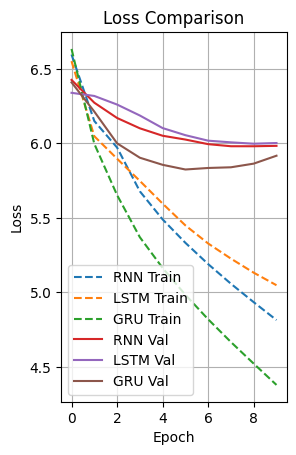

In [22]:
plt.subplot(1,2,1)
plt.plot(rnn_hist.history['loss'], linestyle='--', label='RNN Train')
plt.plot(lstm_hist.history['loss'], linestyle='--', label='LSTM Train')
plt.plot(gru_hist.history['loss'], linestyle='--', label='GRU Train')

plt.plot(rnn_hist.history['val_loss'], label='RNN Val')
plt.plot(lstm_hist.history['val_loss'], label='LSTM Val')
plt.plot(gru_hist.history['val_loss'], label='GRU Val')

plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

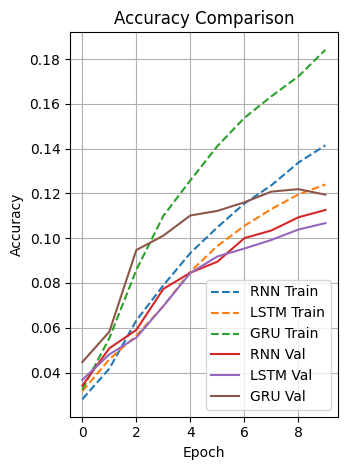

In [23]:
plt.subplot(1,2,2)
plt.plot(rnn_hist.history['accuracy'], linestyle='--', label='RNN Train')
plt.plot(lstm_hist.history['accuracy'], linestyle='--', label='LSTM Train')
plt.plot(gru_hist.history['accuracy'], linestyle='--', label='GRU Train')

plt.plot(rnn_hist.history['val_accuracy'], label='RNN Val')
plt.plot(lstm_hist.history['val_accuracy'], label='LSTM Val')
plt.plot(gru_hist.history['val_accuracy'], label='GRU Val')

plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()